### Read ME
    
Before running the program, please make sure the library have installed on your environment. 
IF get the error ModuleNotFoundError: No module named"". That means the library has not been installed.
    
Using pip function install library.  
Example you got error like ModuleNotFoundError: No module named "wfdb". So put & run this code for install wfdb

       pip install "library name"
   
   <B>pip install wfdb</B> 

at new cell of jupyter notebook. Also use this code for install other library 
    
    

In [1]:
!pip install wfdb

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from IPython.display import display
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os
import shutil
import posixpath

import wfdb
from wfdb import processing
from PIL import Image
import pandas as pd

### ECG Preprocessing
#### First download all data  which can Access at:
    MIT-BIH Normal Sinus Rhythm Database https://physionet.org/content/nsrdb/1.0.0/
    Sudden Cardiac Death Holter Database https://physionet.org/content/sddb/1.0.0/

In [4]:
# function to read signals and convert in picture
def conv_topict(sig, peak_inds, fs, figsize=(75, 10), saveto=None):
    "Plot a signal with its peaks and heart rate"

    N = sig.shape[0]
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    
    ax.plot(sig, color='#3979f0', label='Signal')

    if saveto is not None:
        plt.savefig(saveto, dpi=400)
    plt.show()

### Preprocessing - Normal Dataset

In [5]:
# Read all of the record on Normal dataset
lines = []
with open('/content/drive/My Drive/Thesis/Data/nsrdb/RECORDS') as f:
    lines = f.readlines()[:-1]

for ii in range(0,len(lines)):
    lines[ii] = lines[ii][:-1]
    
lines

['16265',
 '16272',
 '16273',
 '16420',
 '16483',
 '16539',
 '16773',
 '16786',
 '16795',
 '17052',
 '17453',
 '18177',
 '18184',
 '19088',
 '19090',
 '19093',
 '19140']

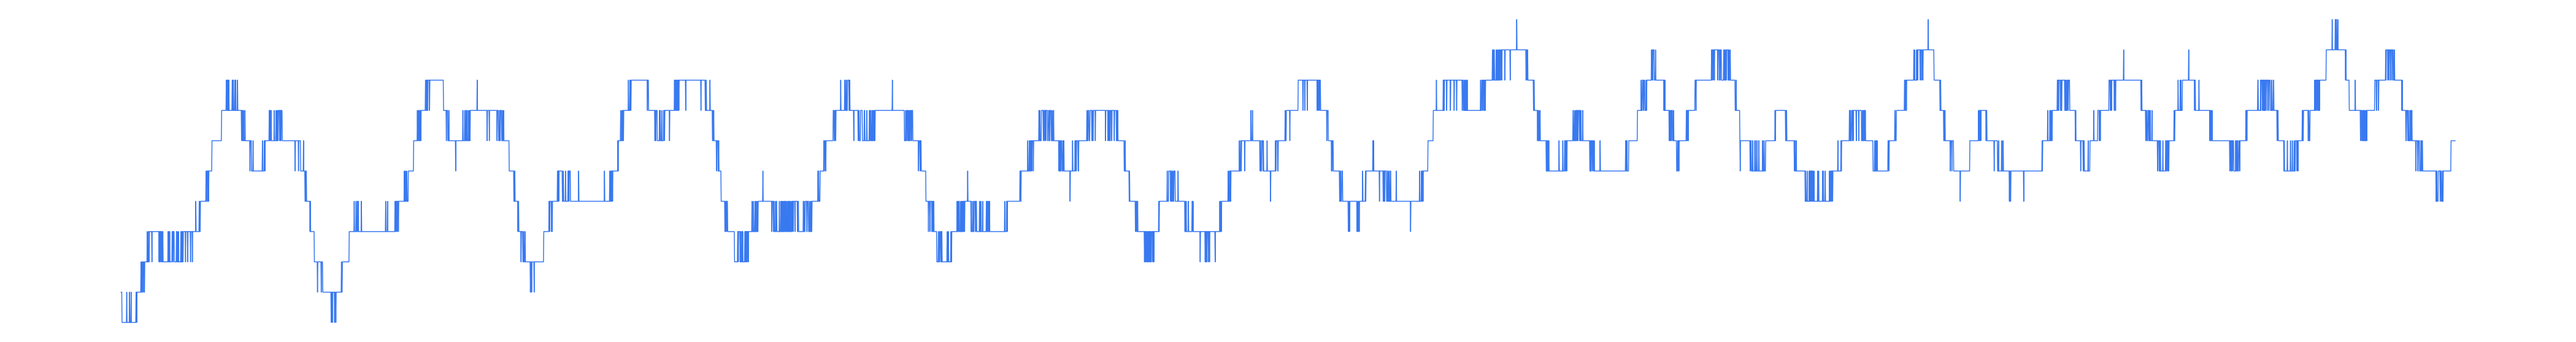

/usr/local/lib/python3.7/dist-packages/PIL/Image.py:2800: DecompressionBombWarning: Image size (120000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  DecompressionBombWarning,


Finishing data 16265


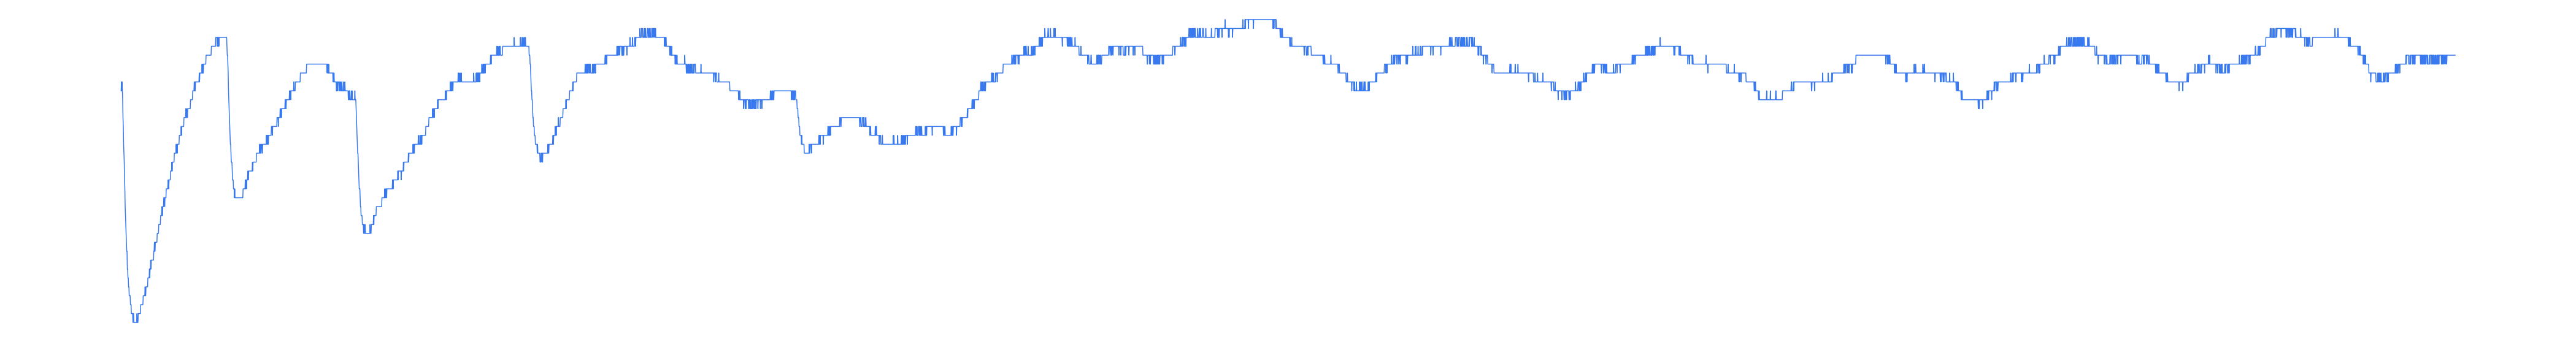

Finishing data 16272


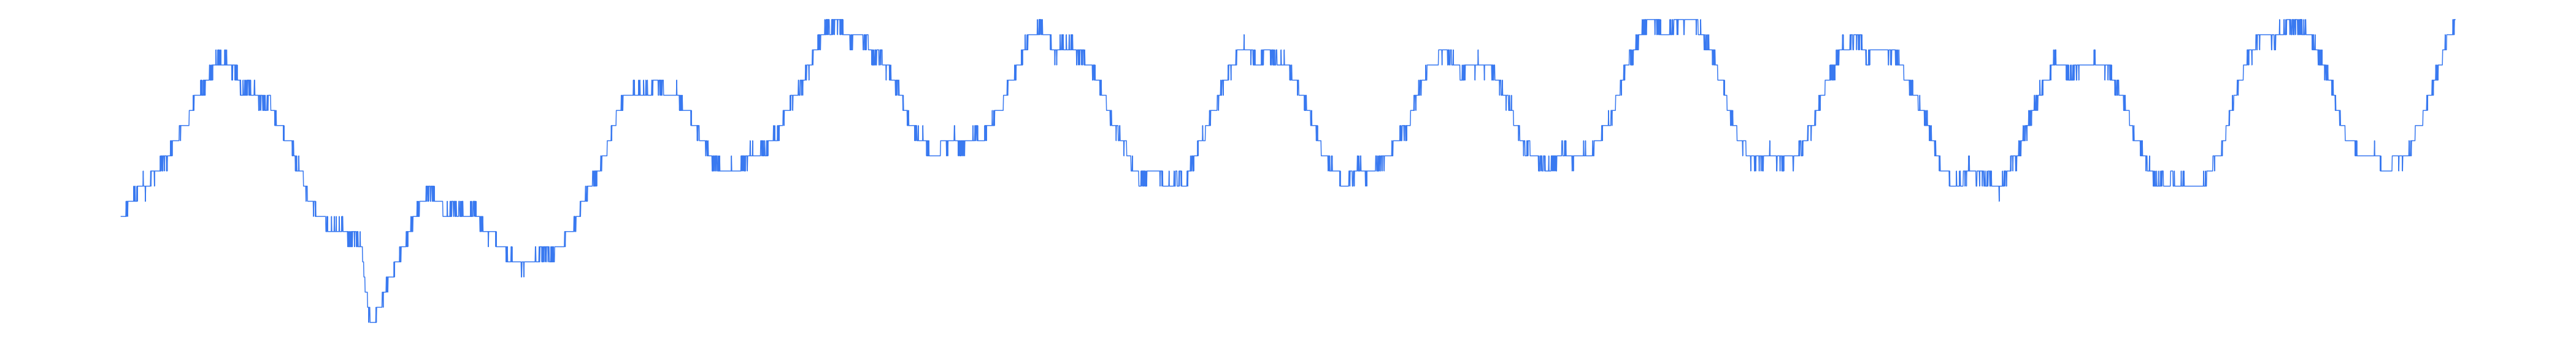

Finishing data 16273


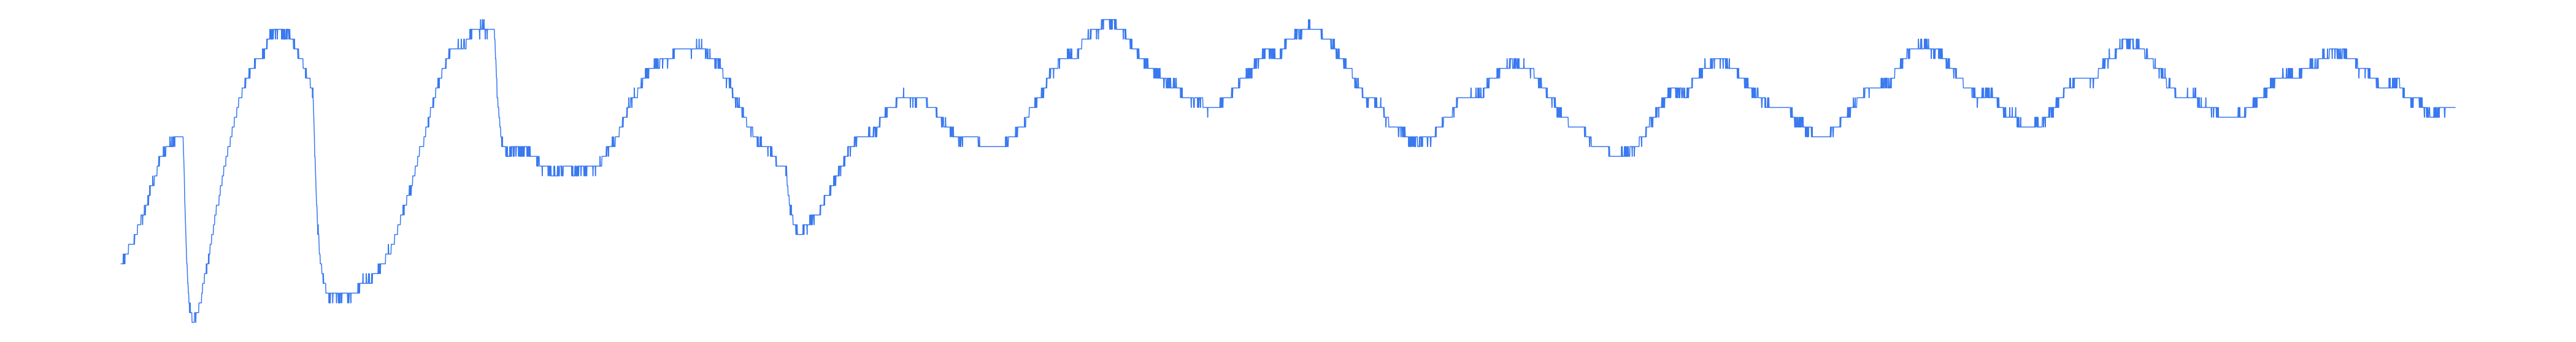

Finishing data 16420


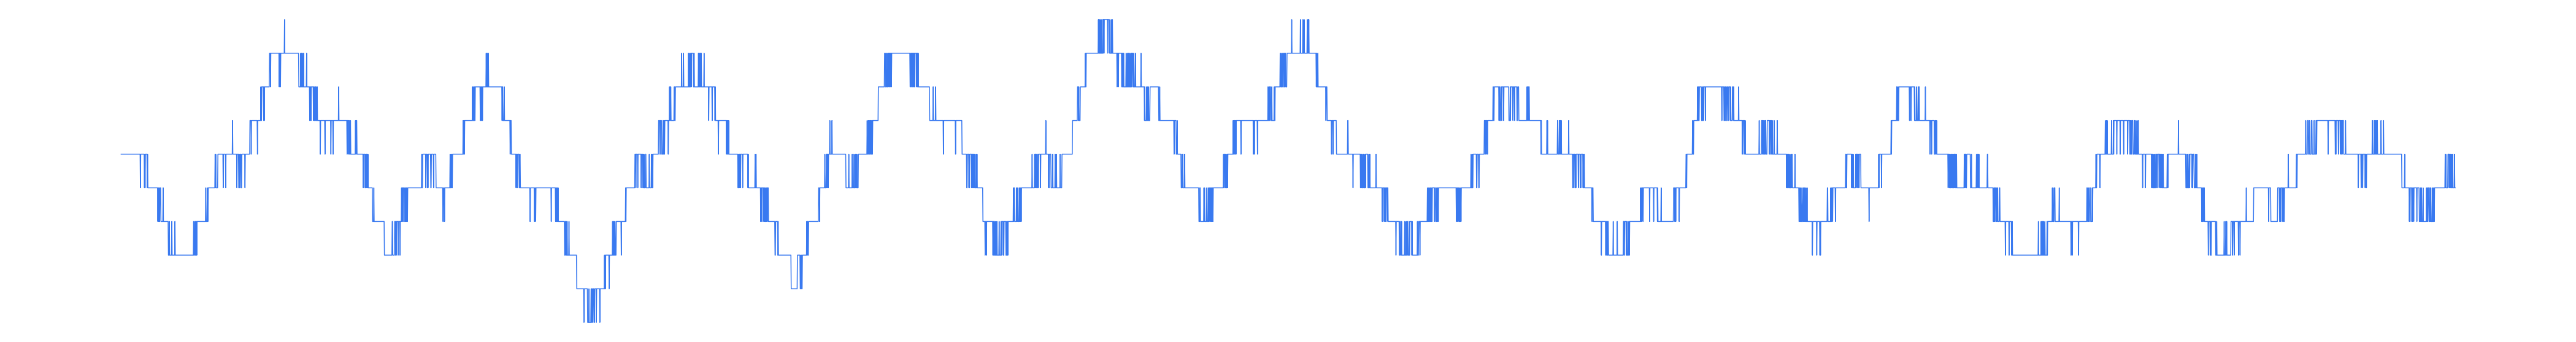

Finishing data 16483


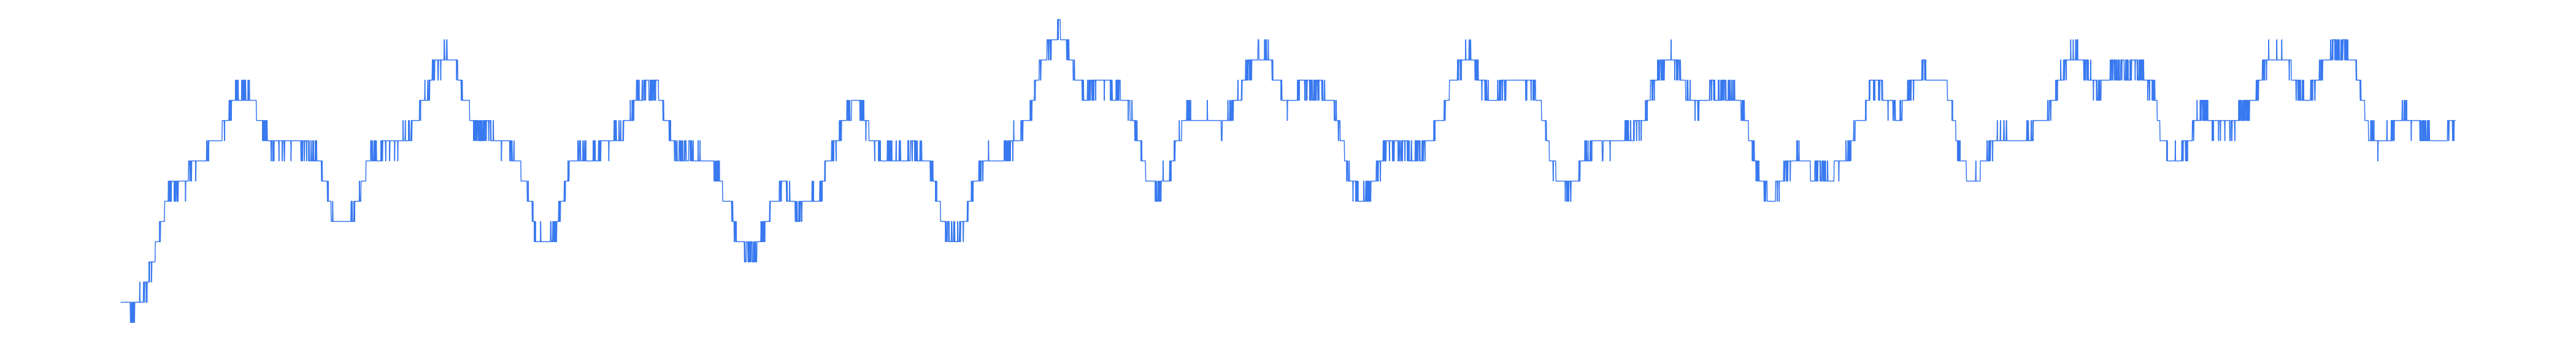

Finishing data 16539


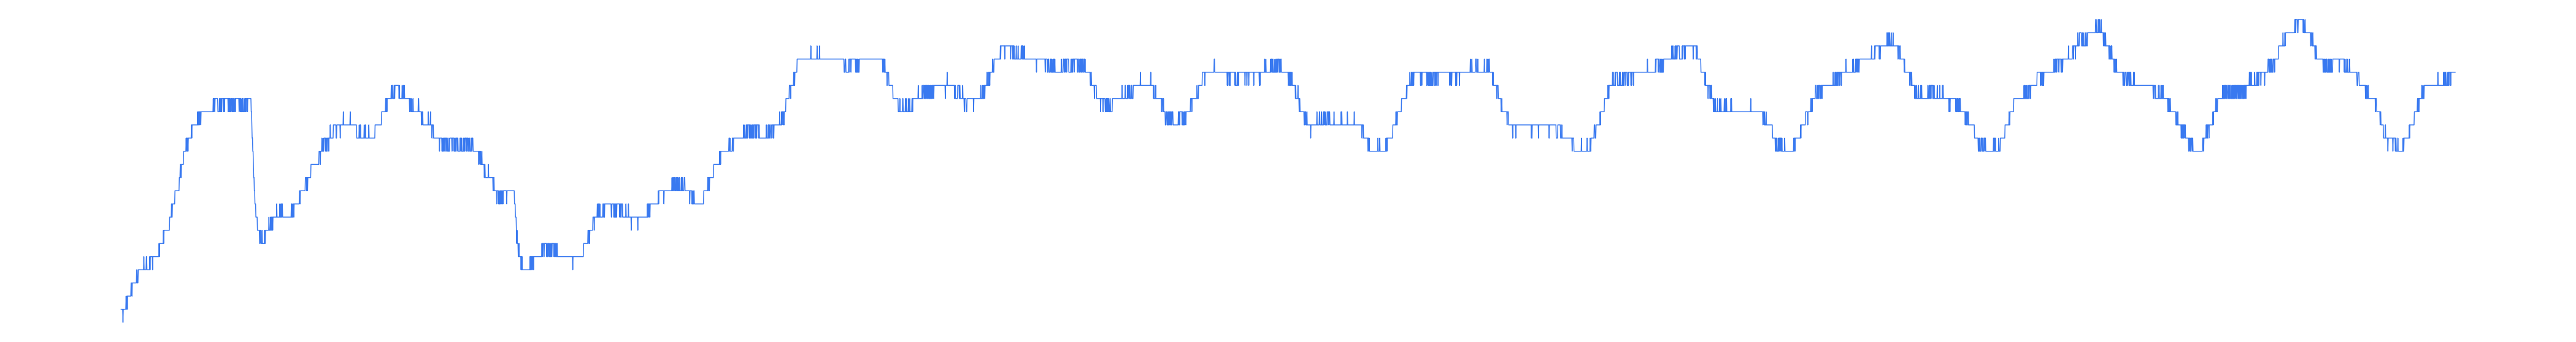

Finishing data 16773


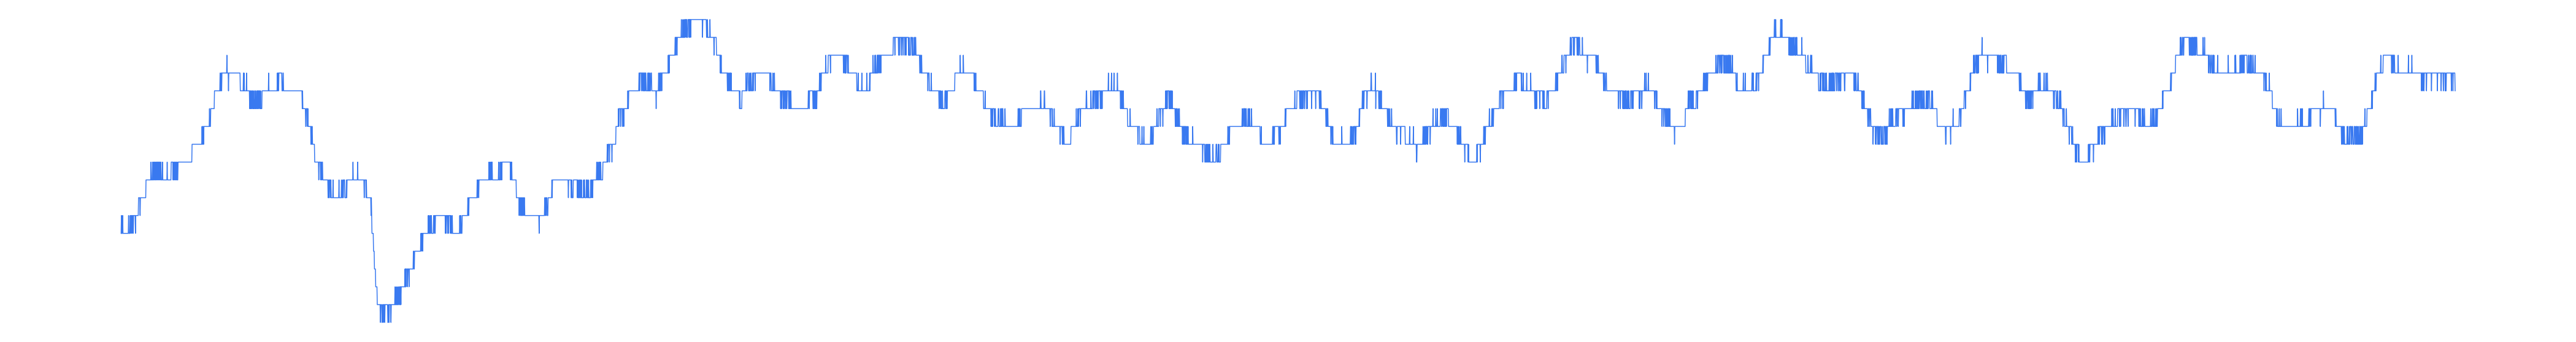

Finishing data 16786


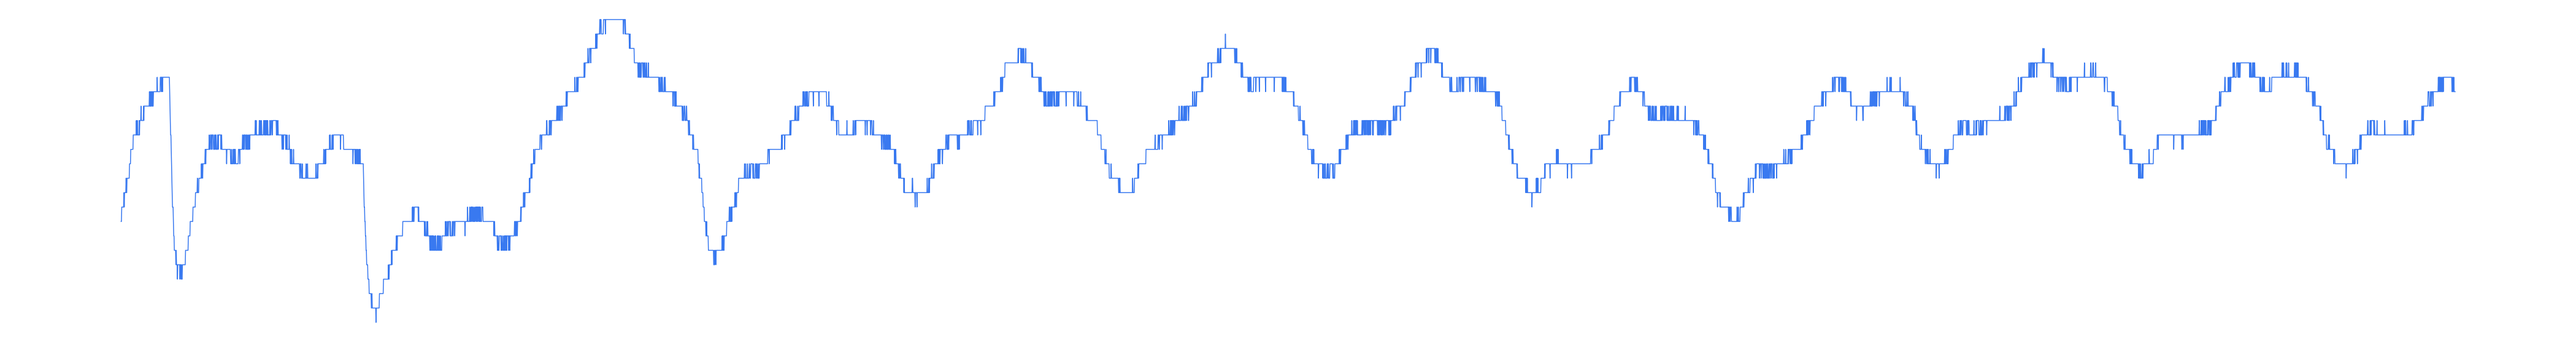

Finishing data 16795


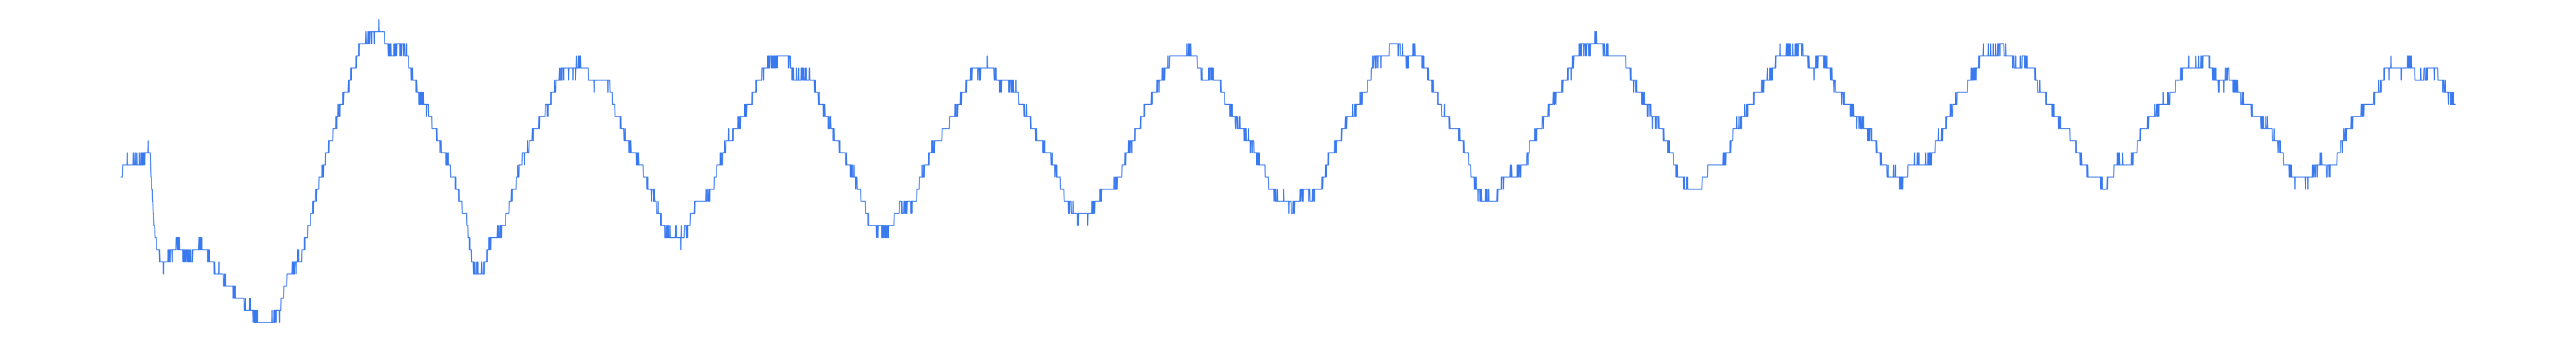

Finishing data 17052


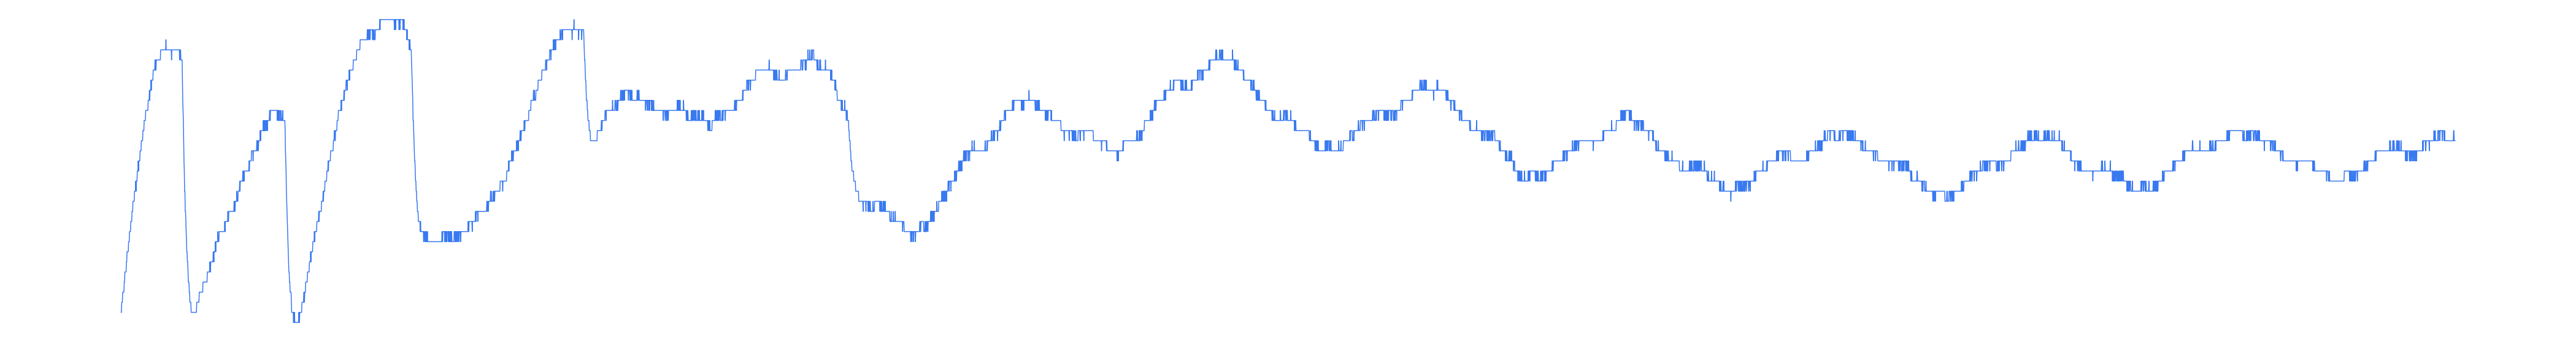

Finishing data 17453


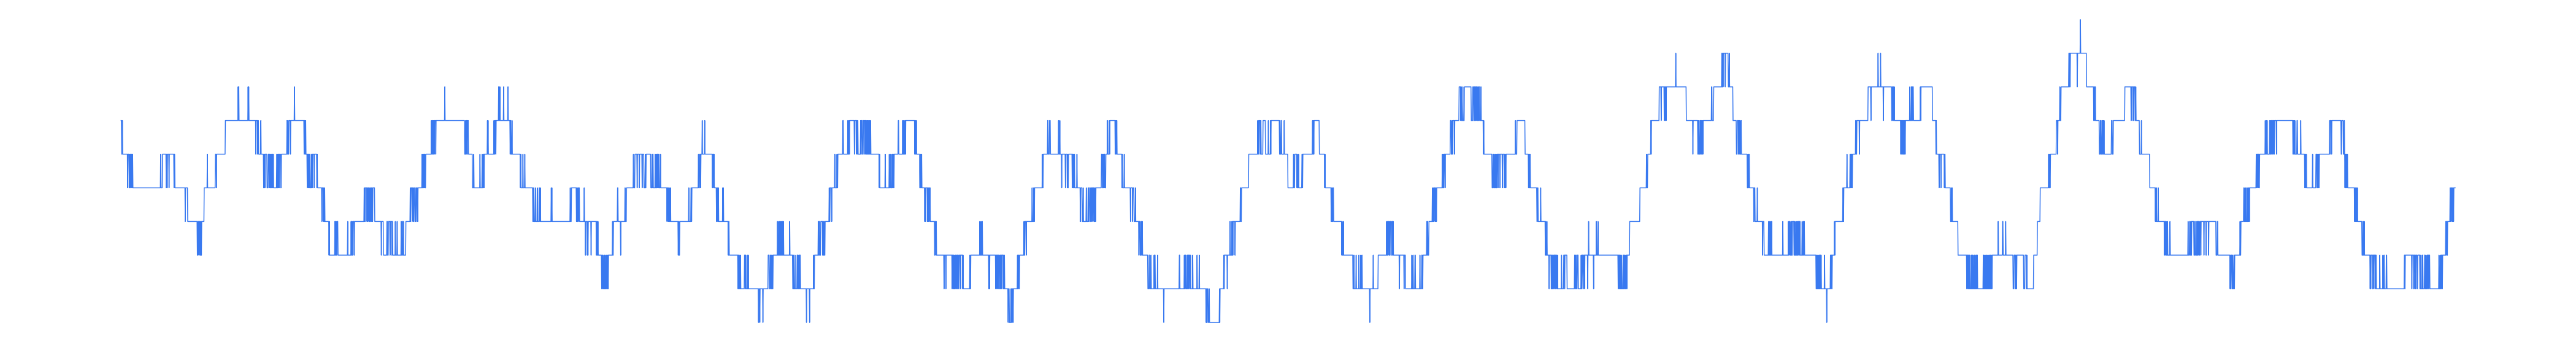

Finishing data 18177


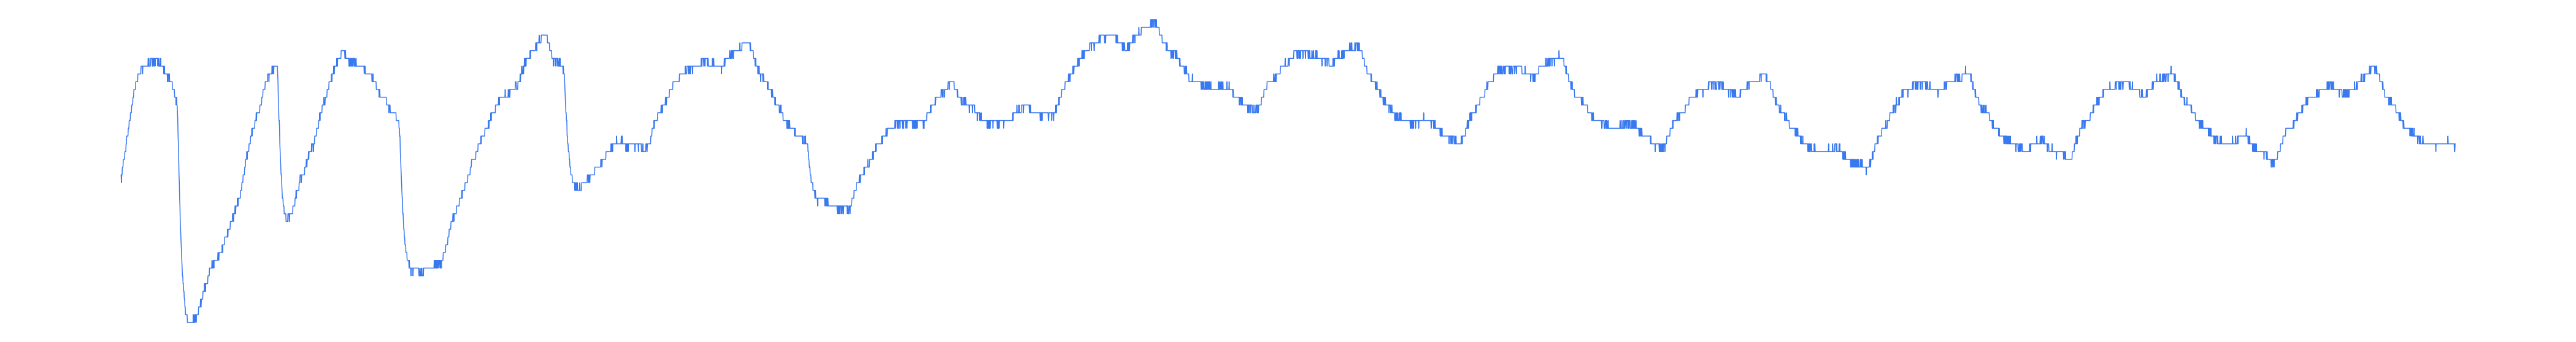

Finishing data 18184


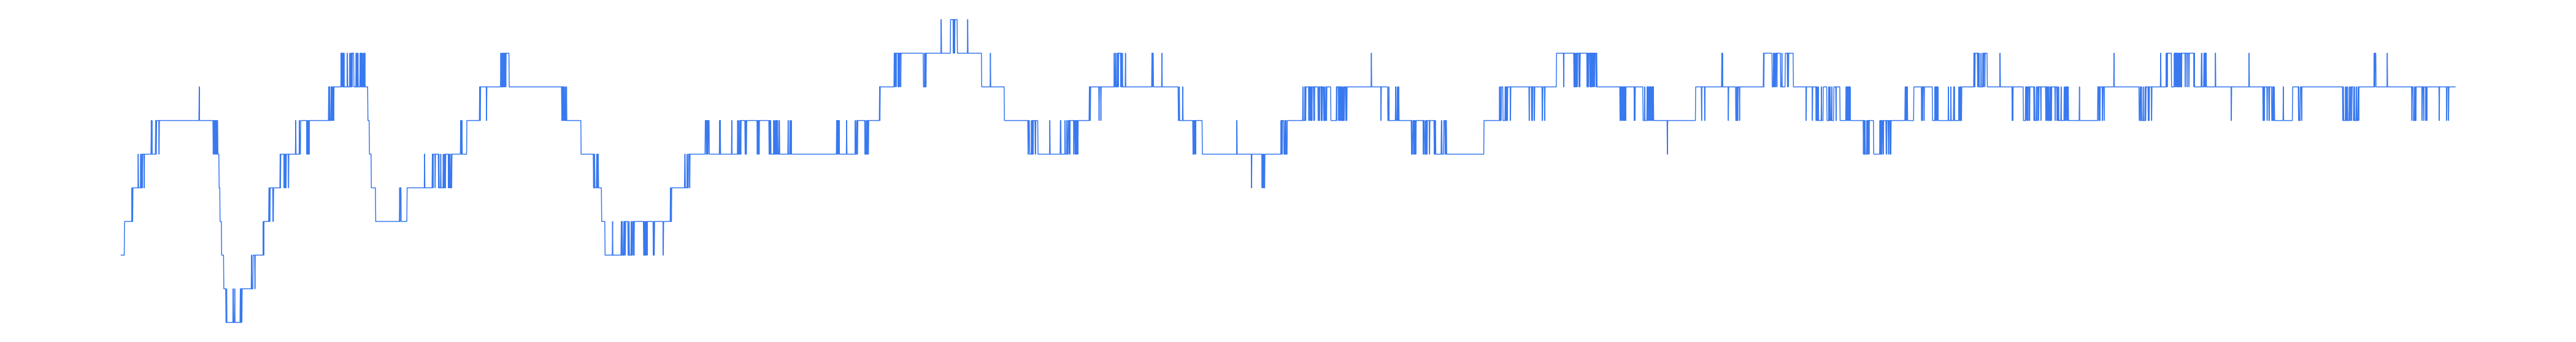

Finishing data 19088


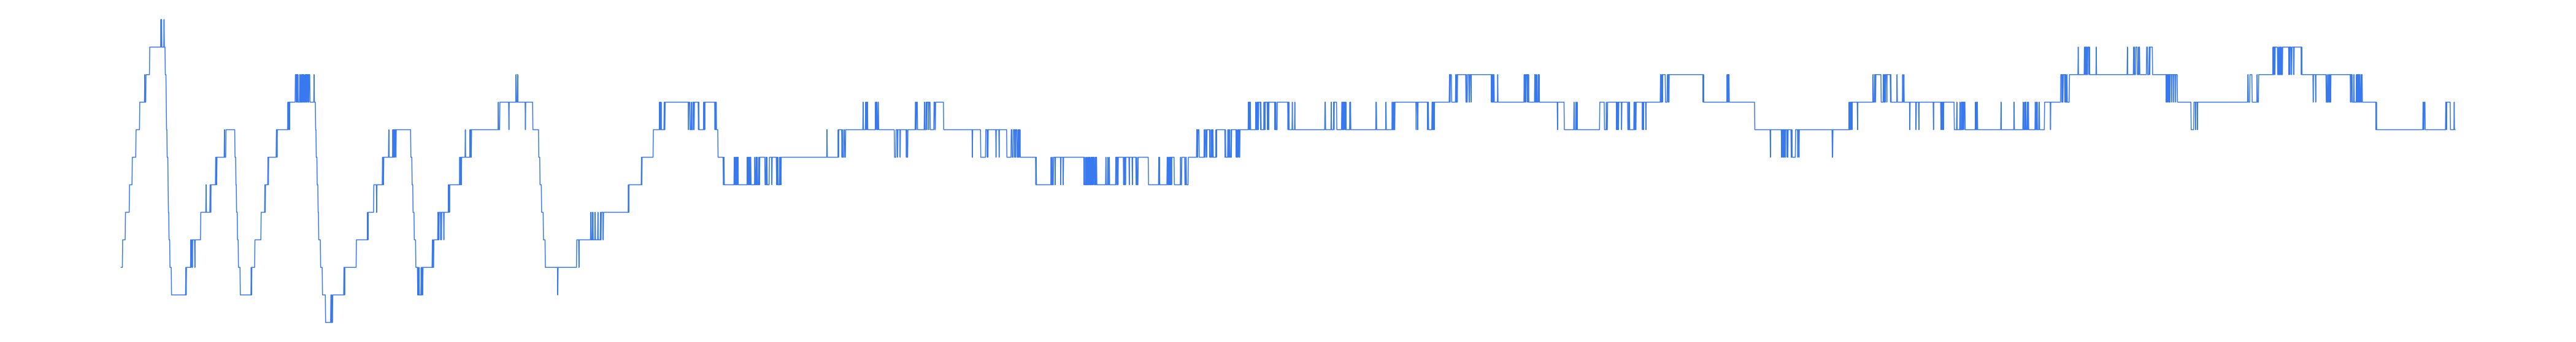

Finishing data 19090


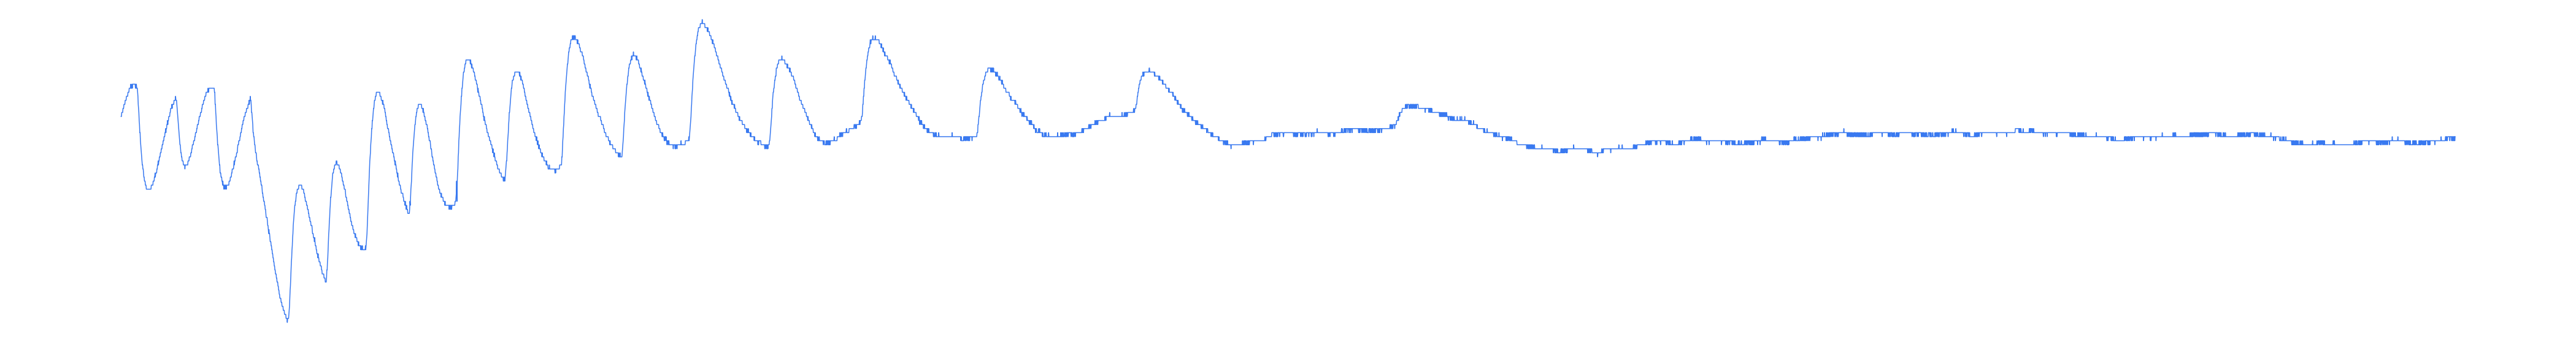

Finishing data 19093


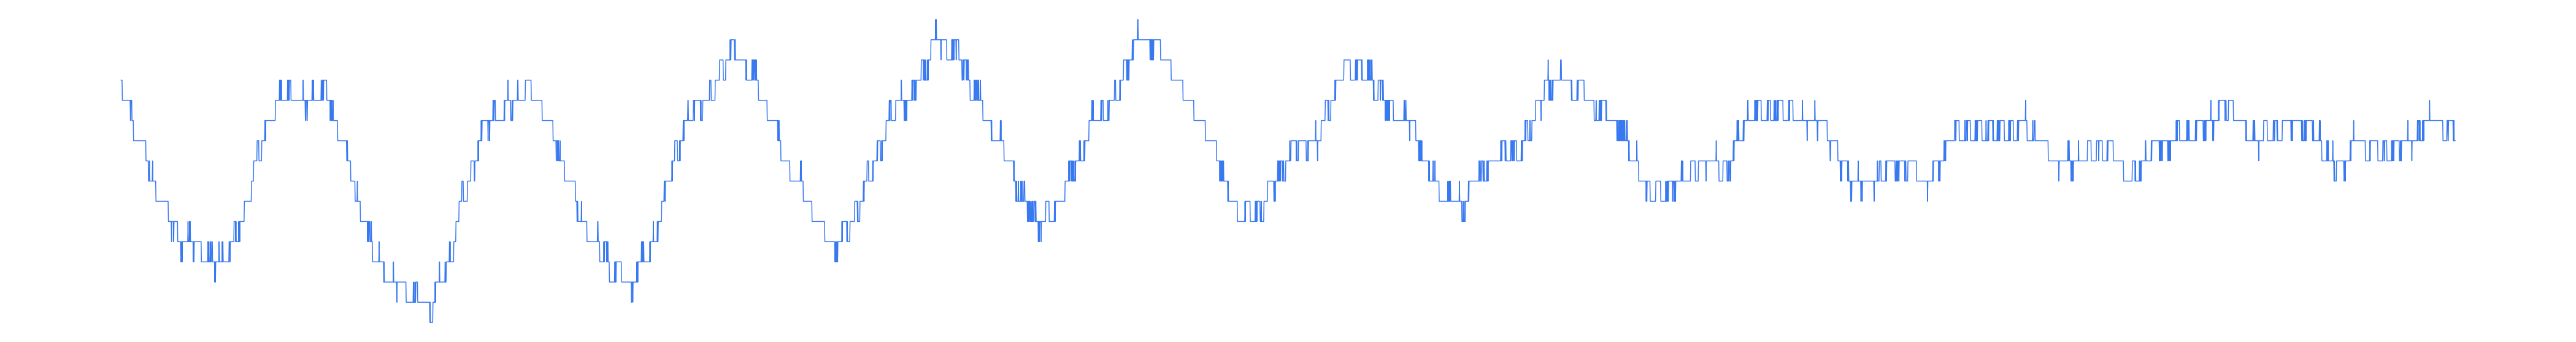

Finishing data 19140


In [6]:
for v in lines:
    dictory = "/content/drive/My Drive/Thesis/Data/nsrdb/"+v
    
    # Calculate time of start and finish 
    record = wfdb.rdrecord(dictory)
    time = record.sig_len # Get length of time

    # Setup value of time frame
    m = (1000*30)/4 # times value, 30 second

    # setup time start and finish
    start = time-m
    finish = time
    
    # directory for saving file of grayscale
    saveto = "/content/drive/My Drive/Thesis/Picture/Normal/"+v+".png"

    # Load the WFDB record and the physical samples
    record = wfdb.rdrecord(dictory, sampfrom=int(start), sampto=finish, channels=[0])

    # Use the GQRS algorithm to detect QRS locations in the first channel
    qrs_inds = processing.qrs.gqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

    # Plot results
    conv_topict(sig=record.p_signal, peak_inds=qrs_inds, fs=record.fs, saveto=saveto)

    # open the image and save as grayscale picture
    img = Image.open(saveto).convert('L')
    
    save_img = "/content/drive/My Drive/Thesis/Grayscale/Normal/normal - "+v+".png"
    img.save(save_img)
    
    print('Finishing data '+v)

### Preprocessing - Sudden Cardiac Death Dataset

In [7]:
vf_dt = pd.read_csv("/content/drive/My Drive/Thesis/Data/VF Data.csv", sep=';')
noVF = vf_dt[vf_dt['VF Onset Time (elapsed)'].str.contains("VF")]['Dat Files'].unique()

# remove no VF from the data
vf_dt = vf_dt[~vf_dt['Dat Files'].isin(noVF)]

for i in range(0,len(noVF)):
    noVF[i] = noVF[i].replace(".dat", "")

noVF

array(['40', '42', '49'], dtype=object)

In [8]:
# Read all of the record on SCD dataset
lines = []
with open('/content/drive/My Drive/Thesis/Data/sddb/RECORDS') as f:
    lines = f.readlines()

for ii in range(0,len(lines)):
    lines[ii] = lines[ii][:-1]
    
# Remove No VF data
for x in noVF:
    lines.remove(x)

lines

['30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '41',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '50',
 '51',
 '52']

In [9]:
vf_dt = vf_dt.reset_index(drop=True)

# check the VF time of data
vf_dt

,Dat Files,Hea Files,Unaudited Annotations,Audited Annotations,Signal Duration,VF Onset Time (elapsed)
0,30.dat,30.hea,30.ari,30.atr,24.33.17,07.54.33
1,31.dat,31.hea,31.ari,31.atr,13.58.40,13.42.24
2,32.dat,32.hea,32.ari,32.atr,24.20.00,16.45.18
3,33.dat,33.hea,33.ari,NaN,24.33.00,04.46.19
4,34.dat,34.hea,34.ari,34.atr,07.05.20,06.35.44
5,35.dat,35.hea,35.ari,35.atr,24.52.00,24.34.56
6,36.dat,36.hea,36.ari,36.atr,20.21.20,18.59.01
7,37.dat,37.hea,37.ari,NaN,25.08.00,01.31.13
8,38.dat,38.hea,38.ari,NaN,18.18.25,08.01.54
9,39.dat,39.hea,39.ari,NaN,05.47.00,04.37.51


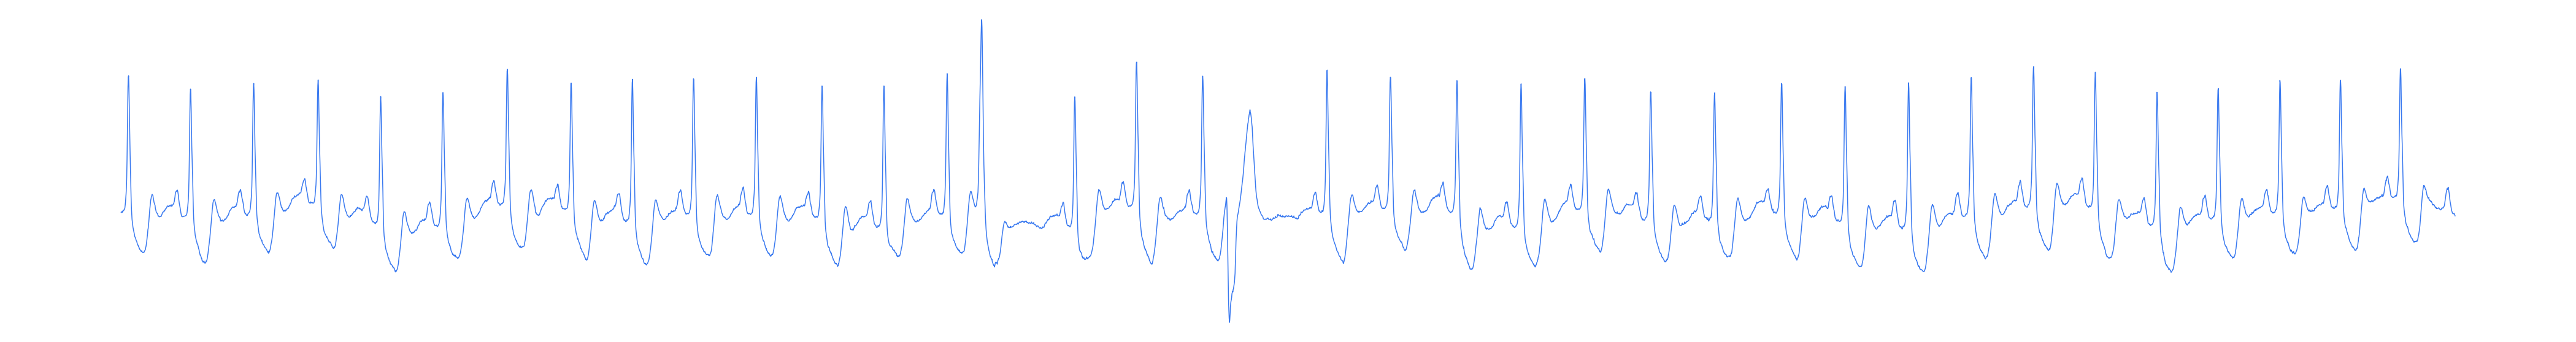

FileNotFoundError: ignored

In [21]:
for i in range(0, len(lines)):
    val = vf_dt.loc[i,  'VF Onset Time (elapsed)'] # Take VF onset time
    v = lines[i]

    # get time of VF the data
    hour = int(val[0:2])*3600000
    minute = int(val[3:5])*60000
    second = int(val[6:8])*1000

    VF = hour + minute + second # Total length of time

    # need to convert to signal len. 1 time = 4 mili second
    VF = VF/4 

    directory = "/content/drive/My Drive/Thesis/Data/sddb/"+v
    
    # get record data from directory
    record = wfdb.rdrecord(directory)

    # Setup value of time frame
    m = (1000*30)/4 # times value, 30 second

    # setup time start and finish
    start = int(VF-m) # start time is VF minus time value
    finish = int(VF) # take from VF onset time
    
    # directory for saving file of grayscale
    saveto = "/content/drive/My Drive/Thesis/Picture/SCD/"+v+".png"

    # Load the WFDB record and the physical samples
    record = wfdb.rdrecord(directory, sampfrom=start, sampto=finish, channels=[0])

    # Use the GQRS algorithm to detect QRS locations in the first channel
    qrs_inds = processing.qrs.gqrs_detect(sig=record.p_signal[:,0], fs=record.fs)

    # Plot results
    conv_topict(sig=record.p_signal, peak_inds=qrs_inds, fs=record.fs)
    
    # open the image and save as grayscale picture
    img = Image.open(saveto).convert('L')
    
    save_img = "/content/drive/My Drive/Thesis/Grayscale/SCD/scd - "+v+".png"
    img.save(save_img)
    
    print('Finishing data '+v)

### Result of the data is Grayscale picture that save on folder 'Grayscale'